In [1]:
import pandas as pd

df = pd.read_csv('data/cvd_synthetic_dataset_v0.2.csv')
df.head()

,patient_id,gender,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack_or_stroke_occurred
0,PT00085957,F,54,25.0,0,161.0,0,1,0,0,0,0,0,NaN,10,0
1,PT00093111,M,31,NaN,0,121.0,0,0,0,0,0,0,0,NaN,10,0
2,PT00058456,M,50,31.3,0,130.0,0,0,0,0,0,0,0,91.027306,10,0
3,PT00016352,M,61,30.0,0,165.0,0,0,0,0,0,0,0,NaN,6,1
4,PT00060611,F,67,32.6,0,166.0,0,0,0,0,0,0,0,NaN,10,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   patient_id                                100000 non-null  str    
 1   gender                                    100000 non-null  str    
 2   age                                       100000 non-null  int64  
 3   body_mass_index                           70115 non-null   float64
 4   smoker                                    100000 non-null  int64  
 5   systolic_blood_pressure                   90133 non-null   float64
 6   hypertension_treated                      100000 non-null  int64  
 7   family_history_of_cardiovascular_disease  100000 non-null  int64  
 8   atrial_fibrillation                       100000 non-null  int64  
 9   chronic_kidney_disease                    100000 non-null  int64  
 10  rheumatoid_arthritis            

In [3]:
df['heart_attack_or_stroke_occurred'].value_counts(normalize=True).round(3) * 100

heart_attack_or_stroke_occurred
0    93.4
1     6.6
Name: proportion, dtype: float64

## Class balance

The target variable `heart_attack_or_stroke_occurred` is heavily imbalanced, with only 6.6% of patients recording a cardiovascular event during the 10-year follow-up period. This reflects real-world CVD incidence in a primary care population and is clinically expected.

This imbalance has important implications for model development and evaluation:

**Why accuracy is misleading here:** A model that predicted "no event" for every patient would achieve 93.4% accuracy while failing to identify a single at-risk patient. In a screening context, this is clinically dangerous.

**False negatives vs false positives:** In CVD risk screening, a false negative — predicting no risk in a patient who goes on to have a heart attack — carries greater clinical harm than a false positive, which results in unnecessary further investigation or preventive treatment. The model should therefore be evaluated with sensitivity as a primary metric, alongside AUC-ROC and the precision-recall curve.

**Handling imbalance:** The logistic regression model will be trained with `class_weight='balanced'` to compensate for the minority class, preventing the model from defaulting to the majority class prediction.

## Exploratory data analysis

### Continuous variables

We begin by examining the distribution of the three continuous clinical variables: age, BMI, and systolic blood pressure. These are the features most likely to show clinically meaningful patterns and will inform our imputation strategy for missing values.

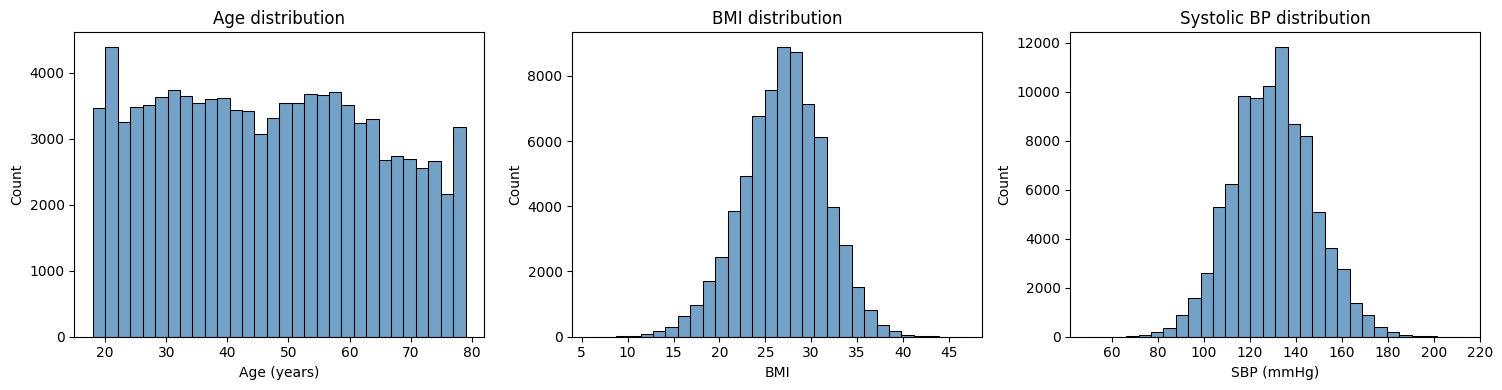

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['age'], ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age (years)')

sns.histplot(df['body_mass_index'].dropna(), ax=axes[1], bins=30, color='steelblue')
axes[1].set_title('BMI distribution')
axes[1].set_xlabel('BMI')

sns.histplot(df['systolic_blood_pressure'].dropna(), ax=axes[2], bins=30, color='steelblue')
axes[2].set_title('Systolic BP distribution')
axes[2].set_xlabel('SBP (mmHg)')

plt.tight_layout()
plt.show()

### Distribution findings

**Age:** The distribution is approximately uniform between 18 and 66, with a gradual taper towards the upper limit of around 80 years. This reflects the synthetic sampling design rather than true UK population demographics, where older age groups would be more heavily represented in a primary care CVD cohort. This is worth noting as a limitation when interpreting model outputs.

**BMI:** Approximately normally distributed with no implausible outliers, suggesting clean simulation. The 30% missingness likely reflects real-world recording patterns — BMI is not routinely measured at every consultation. Given the normal distribution, median imputation is a reasonable strategy.

**Systolic blood pressure:** Also approximately normally distributed. The 10% missingness is clinically realistic — blood pressure may not be recorded at every encounter. Median imputation will be used, though it is worth noting that missingness in SBP may not be random; patients with undiagnosed hypertension are less likely to have had their BP checked.

### Categorical variables

We now examine the prevalence of binary comorbidities and lifestyle variables across the dataset. This gives us a clinical picture of the patient population and helps identify any variables with very low prevalence that may be uninformative for the model.

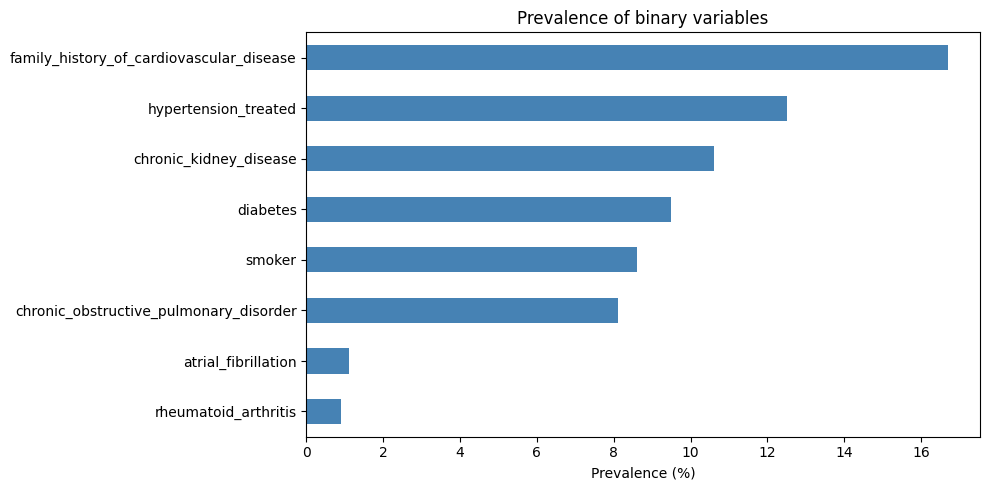

family_history_of_cardiovascular_disease    16.7
hypertension_treated                        12.5
chronic_kidney_disease                      10.6
diabetes                                     9.5
smoker                                       8.6
chronic_obstructive_pulmonary_disorder       8.1
atrial_fibrillation                          1.1
rheumatoid_arthritis                         0.9
dtype: float64


In [6]:
categorical_cols = [
    'smoker', 'hypertension_treated', 'family_history_of_cardiovascular_disease',
    'atrial_fibrillation', 'chronic_kidney_disease', 'rheumatoid_arthritis',
    'diabetes', 'chronic_obstructive_pulmonary_disorder'
]

prevalence = df[categorical_cols].mean().mul(100).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
prevalence.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Prevalence (%)')
ax.set_title('Prevalence of binary variables')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(prevalence)

### Categorical variable prevalence

The prevalence of binary variables across the dataset is broadly consistent with UK primary care epidemiology, with some notable observations:

**Family history of CVD (16.7%)** is the most prevalent variable, which is expected given its common occurrence in the general population and its routine recording in primary care.

**Hypertension treated (12.5%)** reflects patients currently on antihypertensive medication. Interpreted alongside systolic BP readings, this variable is clinically important — treated patients may appear normotensive while carrying elevated underlying vascular risk.

**Chronic kidney disease (10.6%)** is slightly higher than published UK prevalence estimates of 6-7% in adults, likely reflecting the synthetic data generation process rather than true population rates.

**Atrial fibrillation (1.1%) and rheumatoid arthritis (0.9%)** are low prevalence but clinically significant. Their low frequency may limit their predictive contribution to the model individually, though AF in particular is a strong stroke predictor and should be retained.

All variables are retained for model training. No variable is sufficiently rare to justify exclusion on prevalence grounds alone.

### Event rates by variable

We now examine the proportion of patients who experienced a cardiovascular event within each category of the binary variables. This gives us a preliminary indication of which variables are likely to be strong predictors in the model.

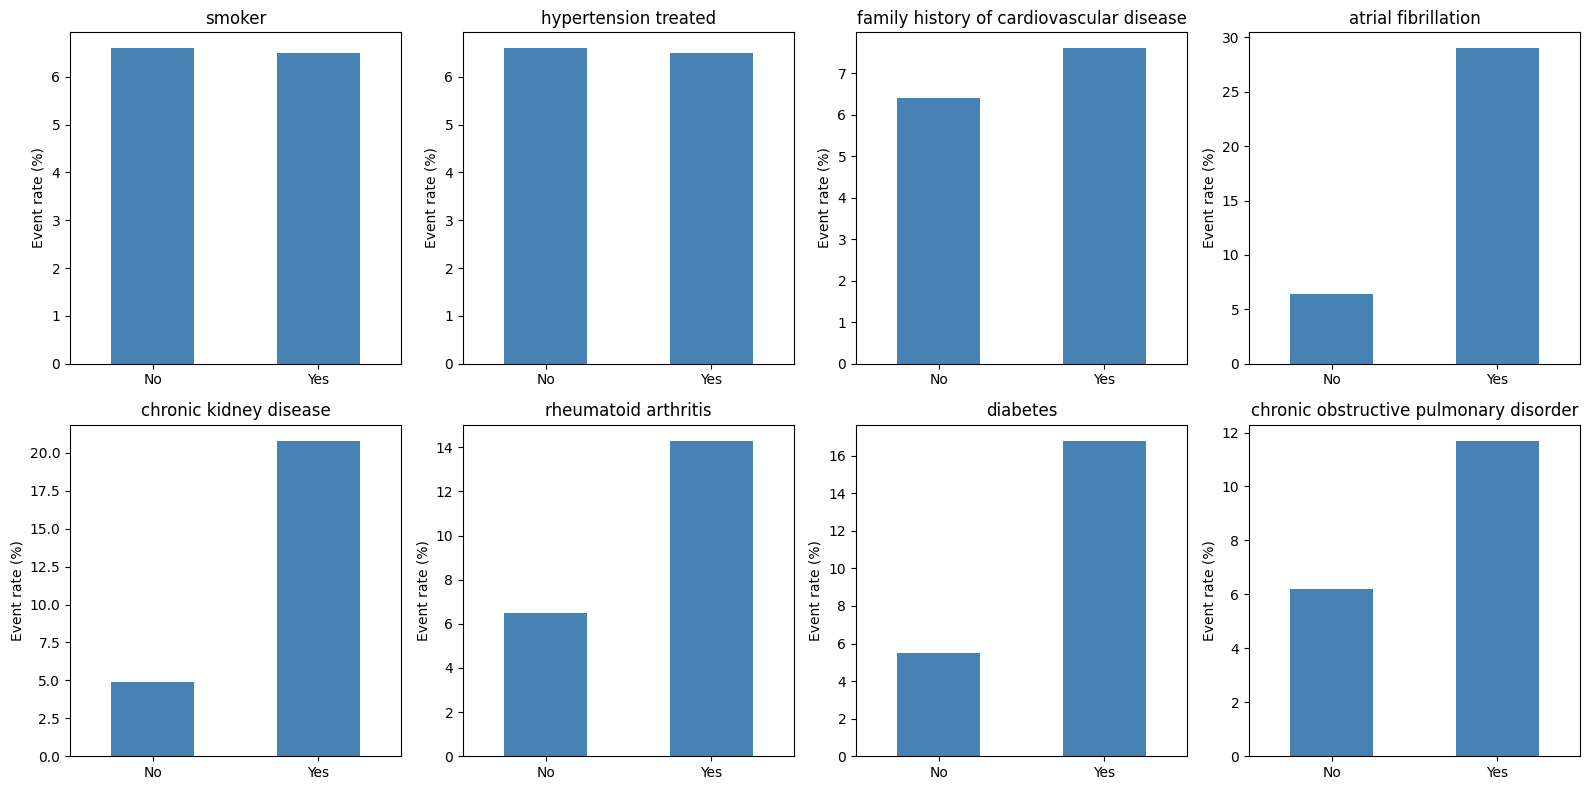

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    event_rate = df.groupby(col)['heart_attack_or_stroke_occurred'].mean().mul(100).round(1)
    event_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Event rate (%)')
    axes[i].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

### Event rates by categorical variable

Examining cardiovascular event rates stratified by binary variables reveals clinically meaningful variation across most comorbidities, with two notable exceptions.

**Atrial fibrillation** shows the strongest association with events (~29% event rate vs 6% in those without AF), consistent with its well-established role as a major thromboembolic stroke risk factor. This is the single most discriminating binary variable in the dataset.

**Chronic kidney disease (~21%), diabetes (~17%), and rheumatoid arthritis (~14%)** all demonstrate substantially elevated event rates compared to their absence, confirming their role as independent cardiovascular risk factors. These variables are likely to carry significant weight in the trained model.

**Smoker and hypertension_treated** show virtually no difference in event rates between groups — a counterintuitive finding that likely reflects deliberate noise introduced during dataset simulation. The paper notes that variables with low predictive contribution were included to simulate real-world data challenges. These variables will be retained for training but their coefficients monitored closely.

**Family history of CVD and COPD** show modest but present associations, consistent with their moderate effect sizes in real-world CVD risk tools.

### Continuous variables vs outcome

We now examine how age, BMI, and systolic blood pressure differ between patients who experienced a cardiovascular event and those who did not.

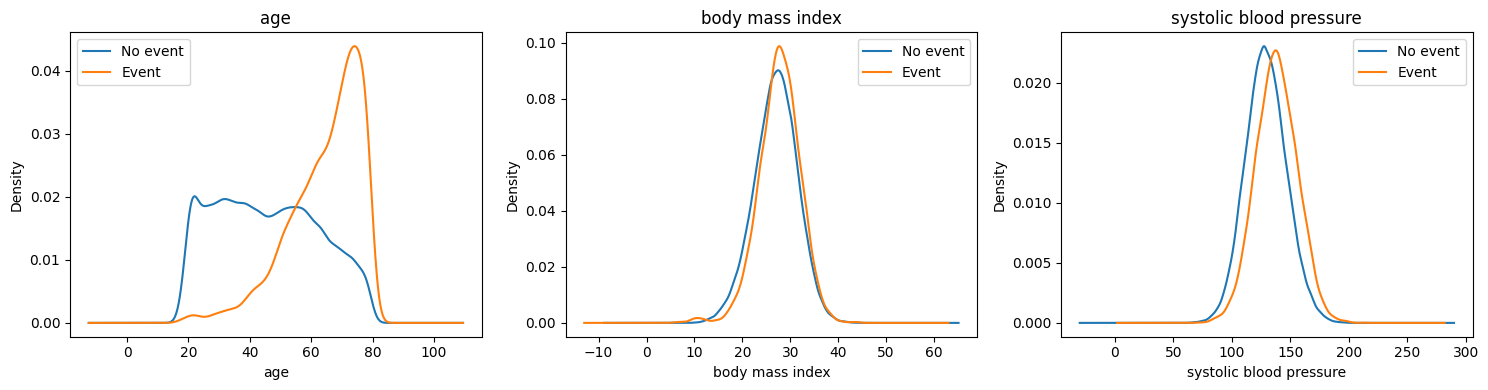

In [8]:
continuous_cols = ['age', 'body_mass_index', 'systolic_blood_pressure']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(continuous_cols):
    df.groupby('heart_attack_or_stroke_occurred')[col].plot(
        kind='kde', ax=axes[i], legend=True
    )
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel(col.replace('_', ' '))
    axes[i].legend(['No event', 'Event'])

plt.tight_layout()
plt.show()

### Continuous variables vs outcome

**Age** shows the most striking separation of any variable in the entire dataset. Patients who experienced a cardiovascular event are heavily concentrated at older ages, with the event distribution peaking sharply around 75-80 years, while the no-event group is distributed broadly across all adult ages. Age is clearly the dominant predictor in this dataset, consistent with its central role in QRISK3 and real-world CVD epidemiology. The model will almost certainly assign it the highest coefficient.

**BMI** shows almost complete overlap between the two groups — the event and no-event distributions are nearly identical. This is a surprising finding given BMI's established role as a cardiovascular risk factor in clinical practice. This likely reflects one of the deliberately introduced low-signal variables noted in the dataset documentation, or may reflect the fact that BMI's effect on CVD risk is largely mediated through other variables already present in the dataset such as diabetes, hypertension, and systolic BP. Despite this, BMI will be retained for training and its coefficient examined.

**Systolic blood pressure** shows a modest but visible rightward shift in the event group, indicating that patients who experienced events had slightly higher average SBP. The separation is subtle compared to age, but clinically expected — SBP is a well-established modifiable CVD risk factor. The overlap is partly explained by the presence of treated hypertensive patients whose SBP readings underestimate their true vascular risk.

### Correlation matrix

We examine correlations between all continuous and binary variables to identify multicollinearity — where two variables carry overlapping information — which can affect model stability and coefficient interpretation.

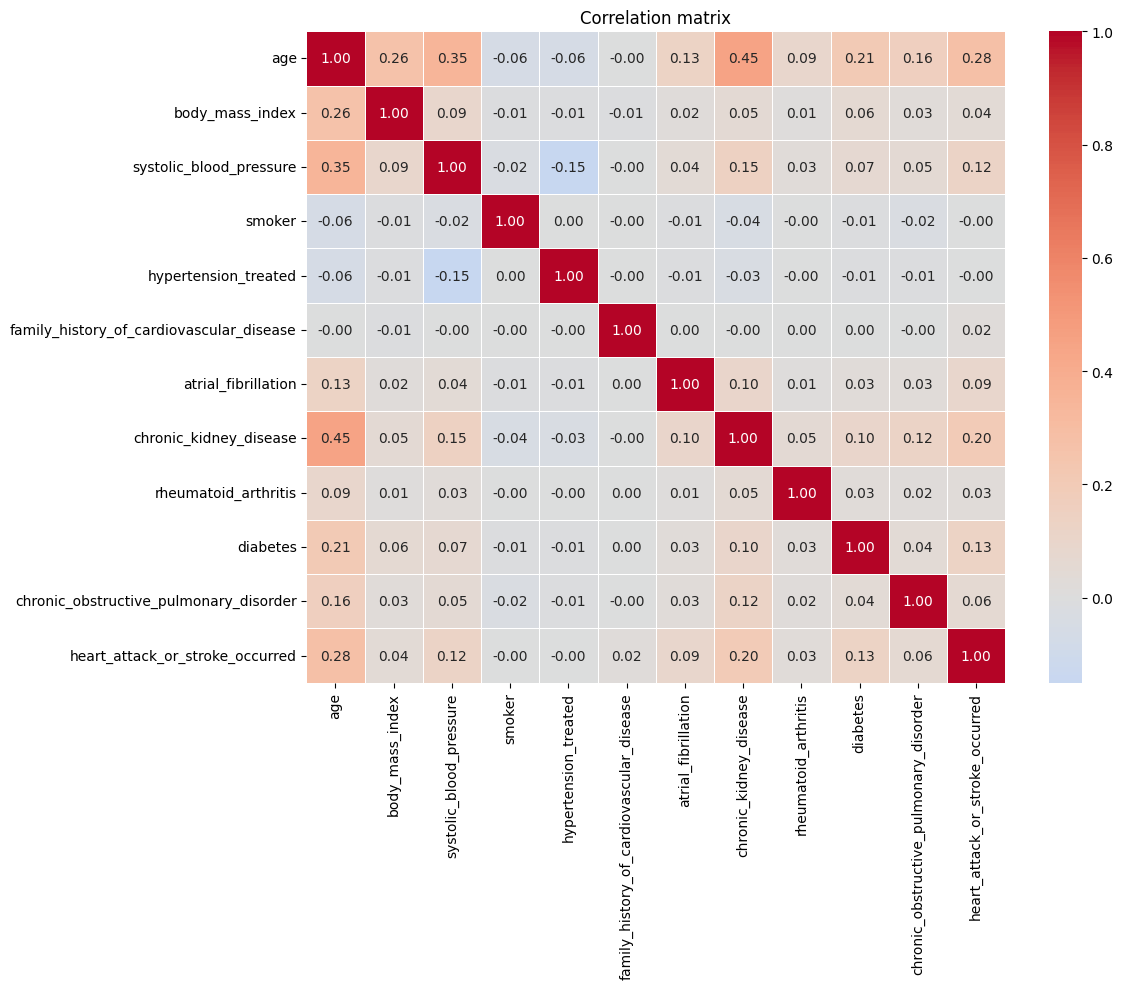

In [9]:
corr_cols = [
    'age', 'body_mass_index', 'systolic_blood_pressure',
    'smoker', 'hypertension_treated', 'family_history_of_cardiovascular_disease',
    'atrial_fibrillation', 'chronic_kidney_disease', 'rheumatoid_arthritis',
    'diabetes', 'chronic_obstructive_pulmonary_disorder',
    'heart_attack_or_stroke_occurred'
]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df[corr_cols].corr().round(2),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

### Correlation matrix findings

**Correlations with the outcome variable (bottom row):**
Age shows the strongest correlation with the outcome (0.28), confirming it as the dominant predictor. CKD (0.20), diabetes (0.13), SBP (0.12), and AF (0.09) follow as the next most correlated variables. Smoker and hypertension_treated show correlations of essentially zero (-0.00) with the outcome, reinforcing the earlier event rate finding that these variables carry minimal predictive signal in this dataset.

**Notable inter-variable correlations:**
The strongest inter-variable correlation is between age and CKD (0.45), which is clinically expected — CKD prevalence rises steeply with age. This introduces some multicollinearity between these two variables, meaning the model may partially attribute CKD's predictive contribution to age and vice versa. This is worth bearing in mind when interpreting coefficients.

Age also correlates moderately with SBP (0.35) and BMI (0.26), again clinically logical — blood pressure and weight tend to increase with age in population-level data.

**Hypertension treated and SBP (-0.15):** The negative correlation here is clinically meaningful — patients on antihypertensive treatment have lower recorded SBP values, reflecting the treatment effect. This confirms that SBP and hypertension_treated carry complementary rather than redundant information and both should be retained.

**No severe multicollinearity:** No two predictor variables exceed a correlation of 0.5, suggesting the feature set is reasonably independent and logistic regression should remain stable.

## Summary of EDA findings

The exploratory analysis reveals a dataset that is broadly well-structured and clinically coherent, with several important findings that will inform preprocessing and modelling decisions:

- Age is the dominant predictor, with a striking concentration of events in older patients
- Atrial fibrillation, CKD, diabetes, and rheumatoid arthritis show the strongest associations with the outcome among binary variables
- Smoker and hypertension_treated show minimal predictive signal, likely reflecting deliberate noise in the synthetic dataset
- BMI and FEV1 have significant missingness (30% and 70% respectively) requiring careful handling
- The dataset is heavily imbalanced (6.6% event rate), requiring class weighting during training
- No severe multicollinearity was identified, supporting the use of logistic regression